# S&P 500 Low Volatility Factor – Exploration

This notebook explores a low volatility factor on a sample of S&P 500 stocks.
We:
- load daily adjusted close prices,
- compute rolling annualized volatility,
- inspect and visualize the factor.

In [19]:
import os
project_path = "/Users/jianxiong/git/SP500/sp500-low-volatility-factor" 
os.chdir(project_path)
print(os.getcwd())

/Users/jianxiong/git/SP500/sp500-low-volatility-factor


In [ ]:
from src.data_loader import load_prices
from src.factor import compute_vol_factor

tickers = ["AAPL", "MSFT", "GOOGL"]
prices = load_prices(tickers, "2021-01-01", "2026-01-01")
prices.tail()

vol = compute_vol_factor(prices, window=60)

Ticker,AAPL,GOOGL,MSFT
Date,,,
2025-12-24,273.302216,313.681702,485.856323
2025-12-26,272.892975,313.102448,485.547699
2025-12-29,273.252350,313.152374,484.940430
2025-12-30,272.573578,313.442017,485.318726
2025-12-31,271.355835,312.593109,481.475861


In [23]:
from src.backtest import run_low_high_vol_backtest

portfolio_returns = run_low_high_vol_backtest(prices, vol, quantile=0.2)
portfolio_returns.tail()

,low_vol,high_vol
2025-08-31,-0.048692,0.109484
2025-09-30,0.022223,0.142818
2025-10-31,-0.000270,0.156684
2025-11-30,-0.048047,0.138661
2025-12-31,-0.025067,-0.021785


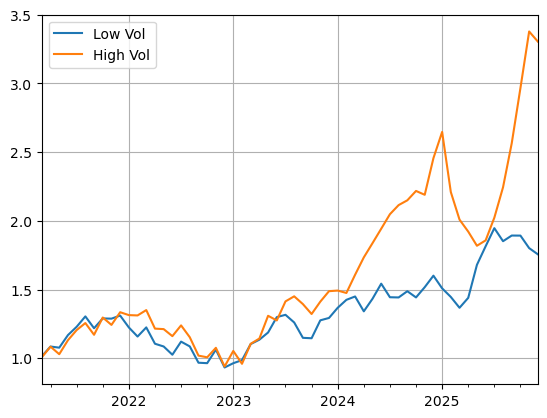

In [25]:
import numpy as np
import matplotlib.pyplot as plt

cum_low = (1 + portfolio_returns["low_vol"]).cumprod()
cum_high = (1 + portfolio_returns["high_vol"]).cumprod()

cum_low.plot(label="Low Vol")
cum_high.plot(label="High Vol")
plt.legend()
plt.grid(True)

In [ ]:
from src.backtest import run_low_high_vol_backtest

tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META"]
prices = load_prices(tickers, "2021-01-01", "2026-01-01")
# You may already have these lines:
# prices = load_prices(...)
# vol = compute_vol_factor(prices, window=60)

vol = compute_vol_factor(prices, window=60)
portfolio_returns = run_low_high_vol_backtest(prices, vol, quantile=0.2)

portfolio_returns.head()

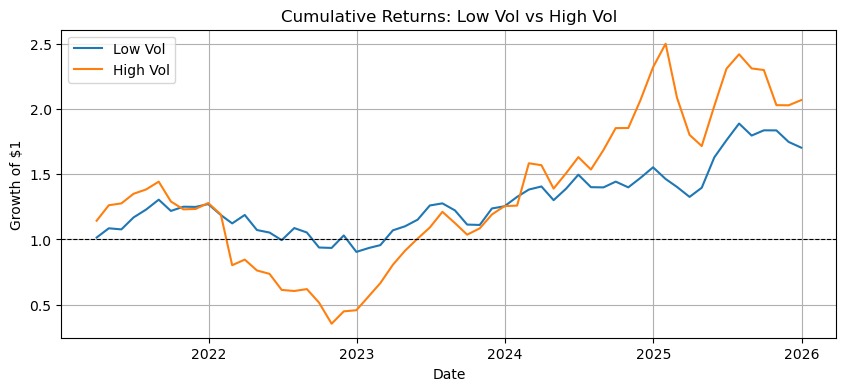

In [27]:
import matplotlib.pyplot as plt

cum_low = (1 + portfolio_returns["low_vol"]).cumprod()
cum_high = (1 + portfolio_returns["high_vol"]).cumprod()

plt.figure(figsize=(10, 4))
plt.plot(cum_low.index, cum_low, label="Low Vol")
plt.plot(cum_high.index, cum_high, label="High Vol")
plt.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
plt.title("Cumulative Returns: Low Vol vs High Vol")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
def sharpe_ratio(returns, periods_per_year=12):
    mean_ret = returns.mean()
    std_ret = returns.std()
    if std_ret == 0 or np.isnan(std_ret):
        return np.nan
    return (mean_ret * periods_per_year) / (std_ret * np.sqrt(periods_per_year))

for col in ["low_vol", "high_vol"]:
    sr = sharpe_ratio(portfolio_returns[col])
    vol_ann = portfolio_returns[col].std() * np.sqrt(12)
    mean_ann = portfolio_returns[col].mean() * 12
    print(f"{col}: mean_ann={mean_ann:.3f}, vol_ann={vol_ann:.3f}, Sharpe={sr:.2f}")

low_vol: mean_ann=0.134, vol_ann=0.219, Sharpe=0.61
high_vol: mean_ann=0.243, vol_ann=0.424, Sharpe=0.57
